In [2]:
import pandas as pd

# Adjust display options to show all columns
pd.set_option('display.max_columns', None)

# Load your dataset into a pandas DataFrame
# Replace 'your_dataset.csv' with the actual path to your dataset file
try:
    df = pd.read_csv('your_dataset.csv')
    print('Dataset loaded successfully. Displaying the first 5 rows:')
    print(df.head())
except FileNotFoundError:
    print("Error: 'your_dataset.csv' not found. Please replace with the correct file path.")
    # If the file is not found, we can't proceed, so raise an error or inform the user.
    # For this exercise, I'll print an error and assume the user will fix it.
    # In a real scenario, you might want to stop or ask for clarification.


Error: 'your_dataset.csv' not found. Please replace with the correct file path.


In [3]:
import pandas as pd

# Adjust display options to show all columns
pd.set_option('display.max_columns', None)

# Load your dataset into a pandas DataFrame
try:
    df = pd.read_csv('/content/sample_data/california_housing_train.csv')
    print('Dataset loaded successfully. Displaying the first 5 rows:')
    print(df.head())
except FileNotFoundError:
    print("Error: Dataset not found. Please ensure the file path is correct.")

Dataset loaded successfully. Displaying the first 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


In [4]:
print("\nDataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB

Missing values per column:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features (all columns are numerical in this dataset)
numerical_features = df.columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
df_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_features]), columns=numerical_features)

print("Scaled DataFrame head:")
print(df_scaled.head())
print("\nScaled DataFrame info:")
df_scaled.info()

Scaled DataFrame head:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   2.619365 -0.671520           -1.079671     1.361695        1.764204   
1   2.539569 -0.573264           -0.761872     2.296608        3.230441   
2   2.494683 -0.905463           -0.920772    -0.882462       -0.866956   
3   2.489696 -0.928857           -1.159121    -0.524186       -0.480230   
4   2.489696 -0.961609           -0.682422    -0.545747       -0.506328   

   population  households  median_income  median_house_value  
0   -0.361184   -0.075998      -1.252543           -1.210558  
1   -0.261865   -0.099404      -1.081483           -1.096745  
2   -0.955354   -0.999252      -1.170105           -1.048461  
3   -0.796793   -0.715774      -0.362600           -1.154514  
4   -0.701830   -0.622148      -1.026454           -1.222629  

Scaled DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column     

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Define a range of k values to test
k_values = range(2, 11) # From 2 to 10

# Initialize lists to store inertia and silhouette scores
inertia_values = []
silhouette_scores = []

# Loop through each k value
for k in k_values:
    # Create a KMeans instance
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init suppresses warning

    # Fit the KMeans model to the scaled DataFrame
    kmeans.fit(df_scaled)

    # Append the inertia to the list
    inertia_values.append(kmeans.inertia_)

    # Calculate and append the silhouette score
    # Silhouette score is defined only for more than one cluster, which is handled by k_values starting from 2
    silhouette_avg = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

print("Inertia values calculated.")
print("Silhouette scores calculated.")

Inertia values calculated.
Silhouette scores calculated.


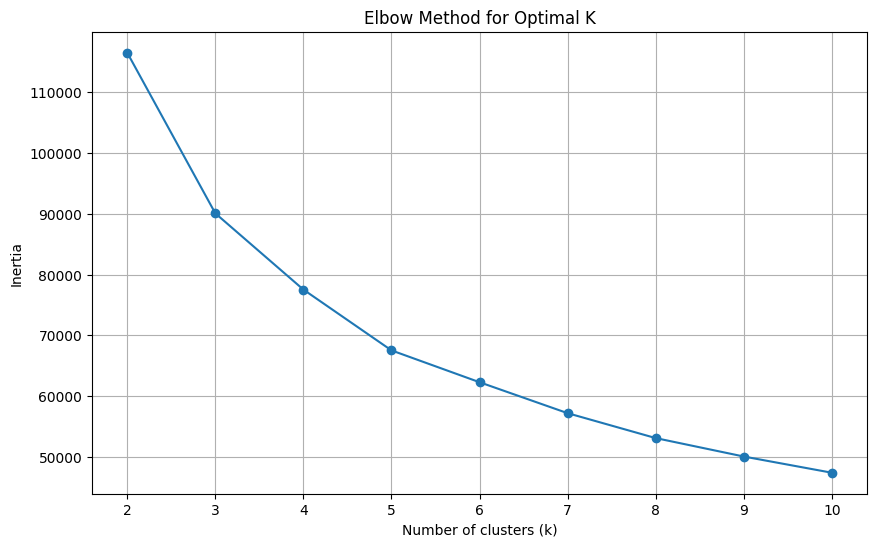

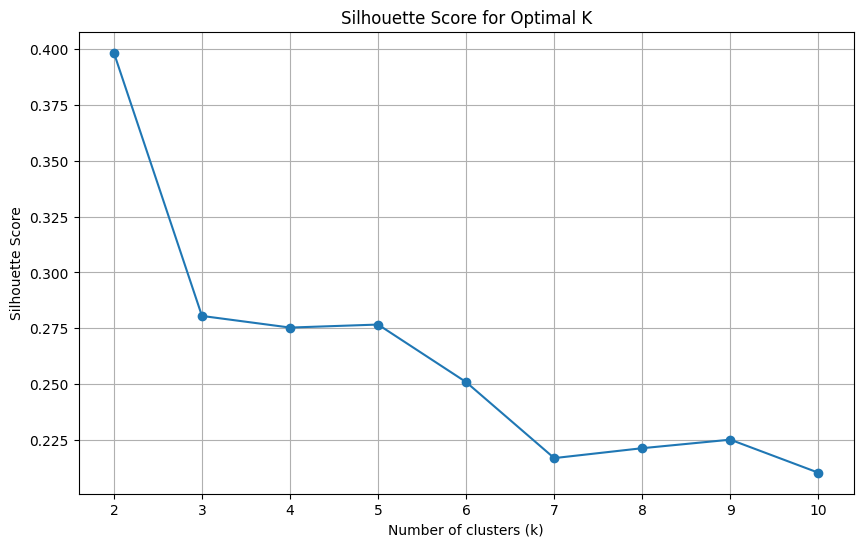

In [7]:
import matplotlib.pyplot as plt

# Create a plot for the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# Create a plot for the Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

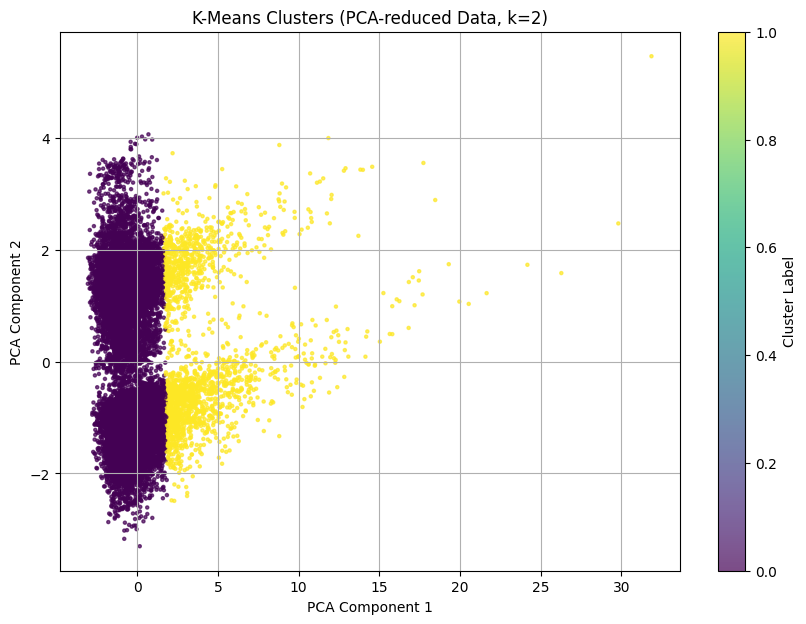

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Instantiate KMeans with n_clusters=2 and random_state=42
kmeans_optimal = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit the KMeans model to the scaled DataFrame and get cluster labels
kmeans_optimal.fit(df_scaled)
cluster_labels = kmeans_optimal.labels_

# Create a PCA object with n_components=2 and random_state=42
pca = PCA(n_components=2, random_state=42)

# Fit and transform the scaled DataFrame using PCA
df_pca = pca.fit_transform(df_scaled)

# Create a scatter plot of the two PCA components, colored by K-Means cluster labels
plt.figure(figsize=(10, 7))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=cluster_labels, cmap='viridis', s=5, alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters (PCA-reduced Data, k=2)')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()


In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Define a list of linkage methods to test
linkage_methods = ['single', 'complete', 'average', 'ward']

# Iterate through each linkage method
for method in linkage_methods:
    print(f"\nGenerating dendrogram for '{method}' linkage method...")
    # Compute the linkage matrix
    linkage_matrix = linkage(df_scaled, method=method)

    # Create a new figure for the dendrogram
    plt.figure(figsize=(15, 7))

    # Plot the dendrogram
    dendrogram(linkage_matrix)

    # Set title and labels
    plt.title(f'Dendrogram for {method.capitalize()} Linkage')
    plt.xlabel('Data Points')
    plt.ylabel('Distance')
    plt.grid(True)
    plt.show()



Generating dendrogram for 'single' linkage method...


RecursionError: maximum recursion depth exceeded

<Figure size 1500x700 with 0 Axes>

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Define a list of linkage methods to test
linkage_methods = ['single', 'complete', 'average', 'ward']

# Iterate through each linkage method
for method in linkage_methods:
    print(f"\nGenerating dendrogram for '{method}' linkage method...")
    # Compute the linkage matrix
    linkage_matrix = linkage(df_scaled, method=method)

    # Create a new figure for the dendrogram
    plt.figure(figsize=(15, 7))

    # Plot the dendrogram, truncating it to avoid RecursionError for large datasets
    # 'lastp' shows only the last p merged clusters
    dendrogram(
        linkage_matrix,
        truncate_mode='lastp',
        p=30,  # Display only the last 30 merged clusters
        show_leaf_counts=True,  # Show the number of points in each leaf
        leaf_rotation=90.,  # Rotate the leaf labels for better readability
        leaf_font_size=12.,  # Increase font size for readability
        show_contracted=True,  # Show a '...' for truncated branches
    )

    # Set title and labels
    plt.title(f'Dendrogram for {method.capitalize()} Linkage (Truncated to last 30 clusters)')
    plt.xlabel('Cluster size or data point index')
    plt.ylabel('Distance')
    plt.grid(True)
    plt.show()



Generating dendrogram for 'single' linkage method...


RecursionError: maximum recursion depth exceeded

<Figure size 1500x700 with 0 Axes>


Generating dendrogram for 'single' linkage method...


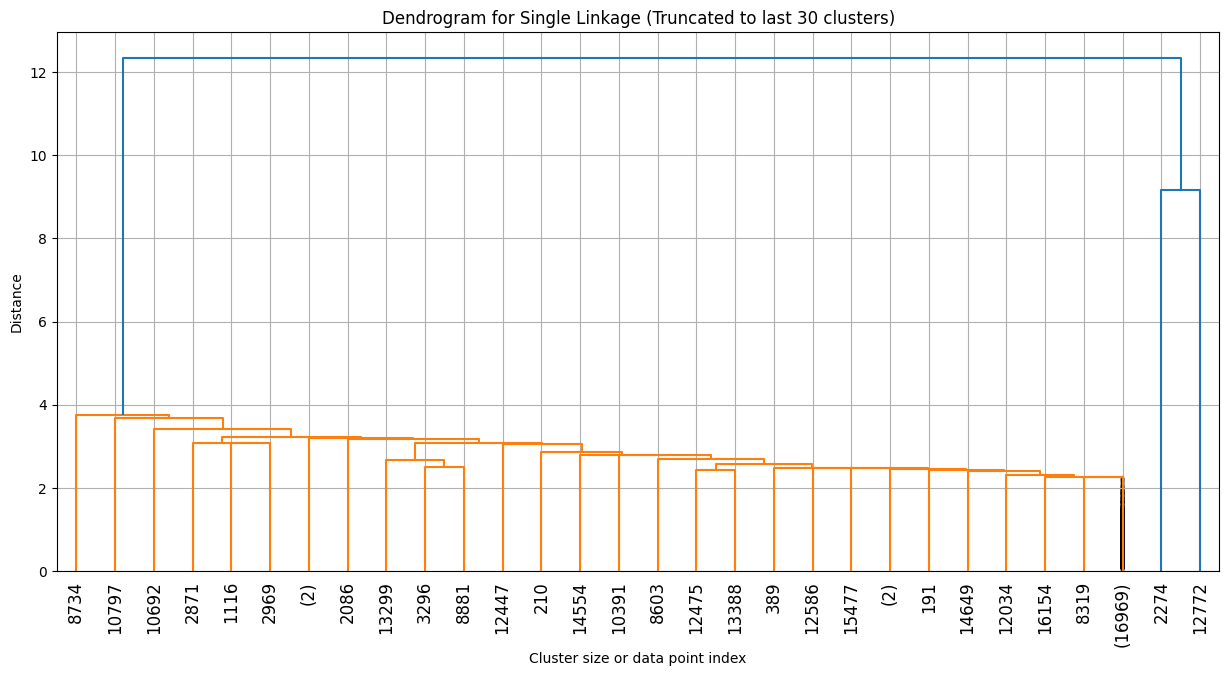


Generating dendrogram for 'complete' linkage method...


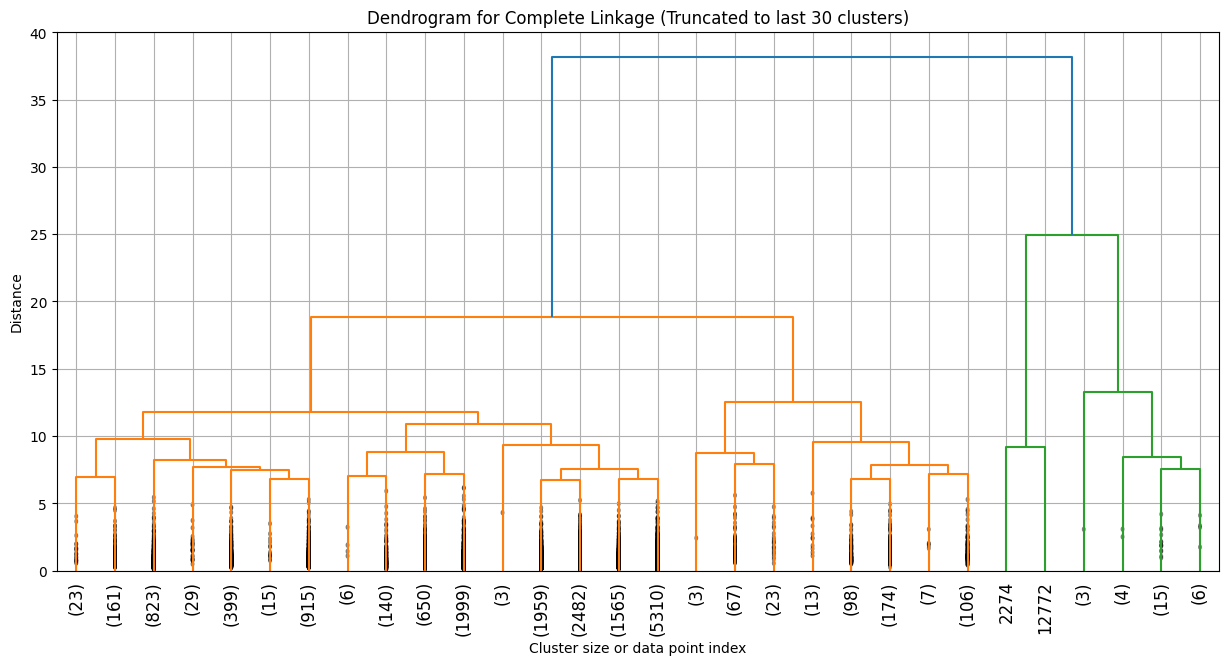


Generating dendrogram for 'average' linkage method...


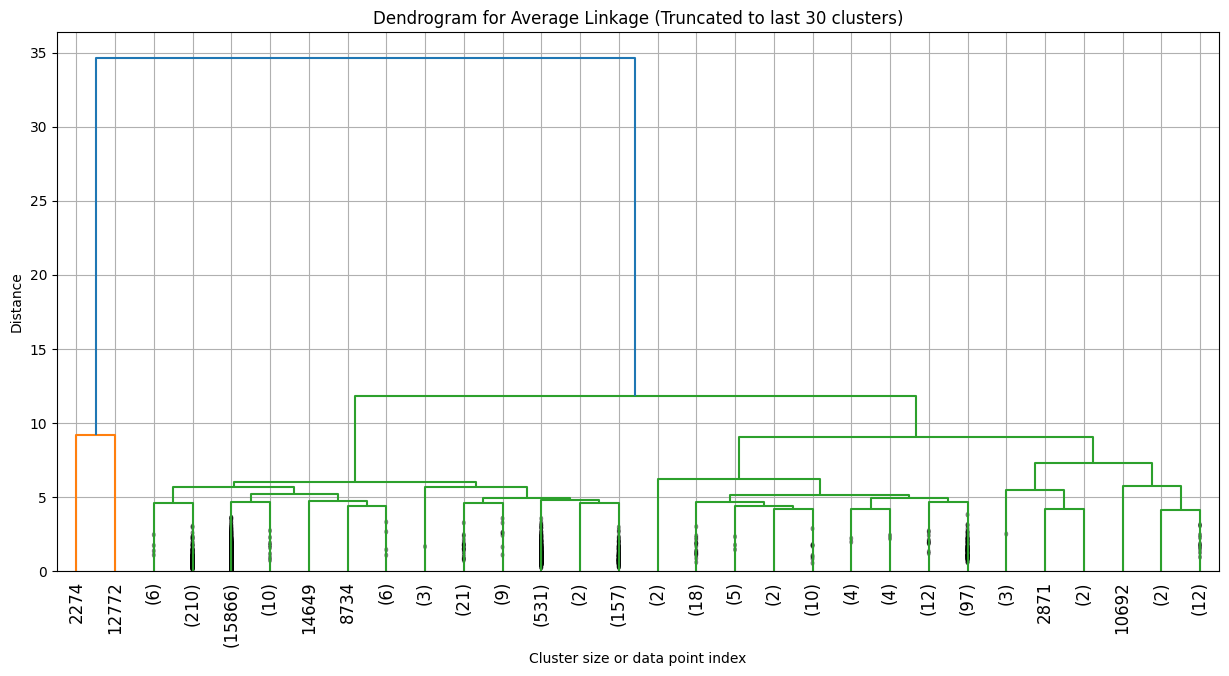


Generating dendrogram for 'ward' linkage method...


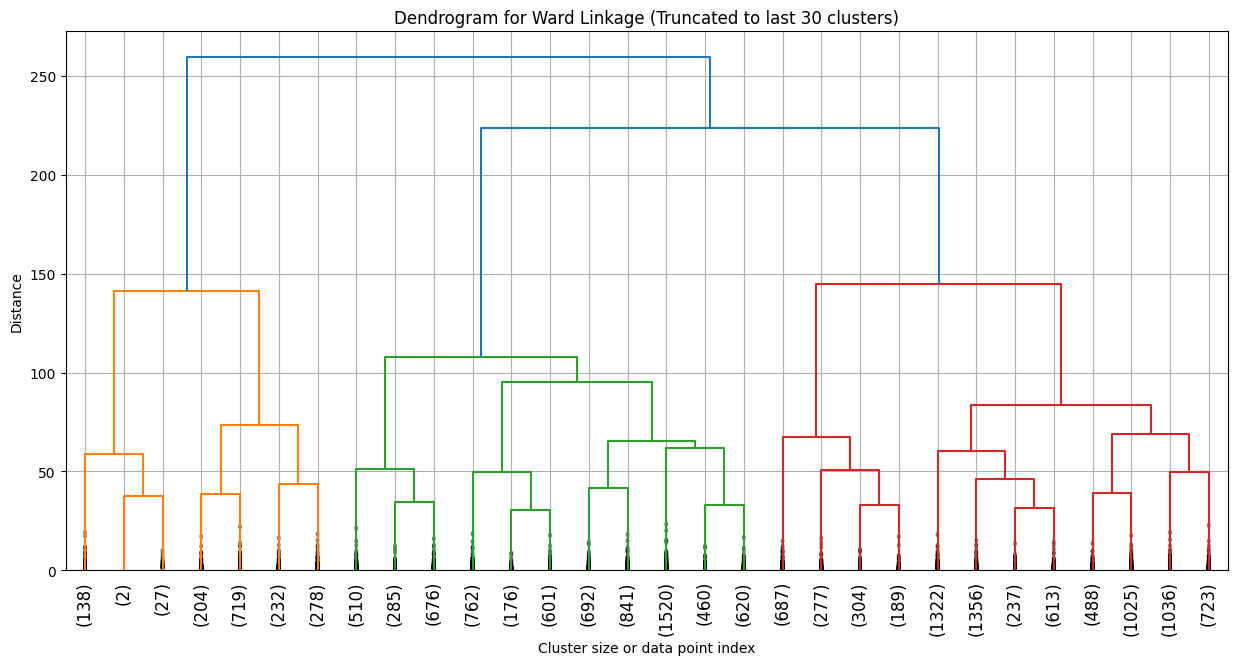

In [12]:
import sys
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Increase the recursion limit for dendrogram plotting
# Be cautious with very high values, as it can lead to stack overflow for deeply nested recursions
sys.setrecursionlimit(10000)

# Define a list of linkage methods to test
linkage_methods = ['single', 'complete', 'average', 'ward']

# Iterate through each linkage method
for method in linkage_methods:
    print(f"\nGenerating dendrogram for '{method}' linkage method...")
    # Compute the linkage matrix
    linkage_matrix = linkage(df_scaled, method=method)

    # Create a new figure for the dendrogram
    plt.figure(figsize=(15, 7))

    # Plot the dendrogram, truncating it to avoid RecursionError for large datasets
    # 'lastp' shows only the last p merged clusters
    dendrogram(
        linkage_matrix,
        truncate_mode='lastp',
        p=30,  # Display only the last 30 merged clusters
        show_leaf_counts=True,  # Show the number of points in each leaf
        leaf_rotation=90.,  # Rotate the leaf labels for better readability
        leaf_font_size=12.,  # Increase font size for readability
        show_contracted=True  # Show a '...' for truncated branches
    )

    # Set title and labels
    plt.title(f'Dendrogram for {method.capitalize()} Linkage (Truncated to last 30 clusters)')
    plt.xlabel('Cluster size or data point index')
    plt.ylabel('Distance')
    plt.grid(True)
    plt.show()


## Analyze Cluster Characteristics

### Subtask:
For both K-Means (with optimal k) and Hierarchical Clustering (with chosen optimal clusters), analyze the characteristics of each cluster by examining the mean or median values of the original features within each cluster. Provide descriptive statistics for each cluster.


**Reasoning**:
The first step is to add the K-Means cluster labels (which were determined as `cluster_labels` from the previous K-Means analysis) to the original DataFrame `df` as a new column named 'KMeans_Cluster' for further analysis.



In [13]:
df['KMeans_Cluster'] = cluster_labels

print("K-Means cluster labels added to DataFrame. Displaying head with new column:")
print(df.head())

K-Means cluster labels added to DataFrame. Displaying head with new column:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  KMeans_Cluster  
0      1015.0       472.0         1.4936             66900.0               0  
1      1129.0       463.0         1.8200             80100.0               1  
2       333.0       117.0         1.6509             85700.0               0  
3       515.0       226.0         3.1917             73400.0               0  
4       624.0       262.0         1.9250             65500.0               0  

**Reasoning**:
Now that K-Means cluster labels have been added to the DataFrame, I will calculate and display the mean characteristics for each K-Means cluster to understand their distinct features.



In [14]:
print("\nMean characteristics of each K-Means cluster:")
print(df.groupby('KMeans_Cluster').mean())


Mean characteristics of each K-Means cluster:
                 longitude   latitude  housing_median_age  total_rooms  \
KMeans_Cluster                                                           
0              -119.611919  35.673888           30.048985  2085.498968   
1              -119.183170  35.255018           17.485063  6889.961013   

                total_bedrooms   population   households  median_income  \
KMeans_Cluster                                                            
0                   426.884592  1148.884992   399.039867       3.845062   
1                  1395.464810  3564.941772  1278.581772       4.176595   

                median_house_value  
KMeans_Cluster                      
0                    205292.840067  
1                    222577.512911  


In [15]:
from scipy.cluster.hierarchy import linkage

# Compute the linkage matrix using the 'ward' method
linkage_matrix_hc = linkage(df_scaled, method='ward')

print("Linkage matrix for Hierarchical Clustering (ward method) computed.")

Linkage matrix for Hierarchical Clustering (ward method) computed.


In [16]:
from scipy.cluster.hierarchy import fcluster

# Determine hierarchical cluster labels for 2 clusters
hc_cluster_labels = fcluster(linkage_matrix_hc, t=2, criterion='maxclust')

# Add these labels to the original DataFrame
df['HC_Cluster'] = hc_cluster_labels

print("Hierarchical cluster labels added to DataFrame. Displaying head with new column:")
print(df.head())

Hierarchical cluster labels added to DataFrame. Displaying head with new column:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  KMeans_Cluster  \
0      1015.0       472.0         1.4936             66900.0               0   
1      1129.0       463.0         1.8200             80100.0               1   
2       333.0       117.0         1.6509             85700.0               0   
3       515.0       226.0         3.1917             73400.0               0   
4       624.0       262.0         1.9250             65500.0        

In [17]:
print("\nMean characteristics of each Hierarchical Cluster:")
print(df.groupby('HC_Cluster').mean())


Mean characteristics of each Hierarchical Cluster:
             longitude   latitude  housing_median_age  total_rooms  \
HC_Cluster                                                           
1          -118.512488  34.620112           16.712500  7107.393750   
2          -119.671160  35.729652           29.823312  2179.900325   

            total_bedrooms   population   households  median_income  \
HC_Cluster                                                            
1              1455.157500  3776.800000  1324.979375       3.942500   
2               444.268312  1185.706299   415.636753       3.877456   

            median_house_value  KMeans_Cluster  
HC_Cluster                                      
1                203070.708750        0.909375  
2                207740.414026        0.033766  



Generating dendrogram for 'single' linkage method (sample size: 500)...


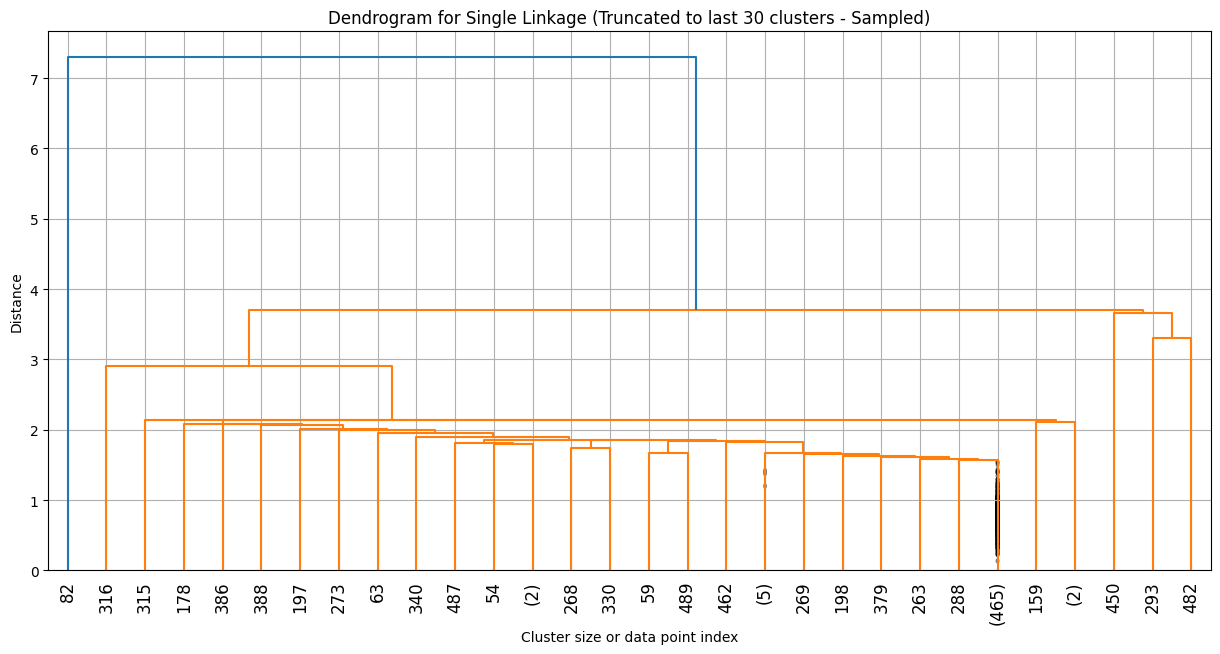


Generating dendrogram for 'complete' linkage method (sample size: 500)...


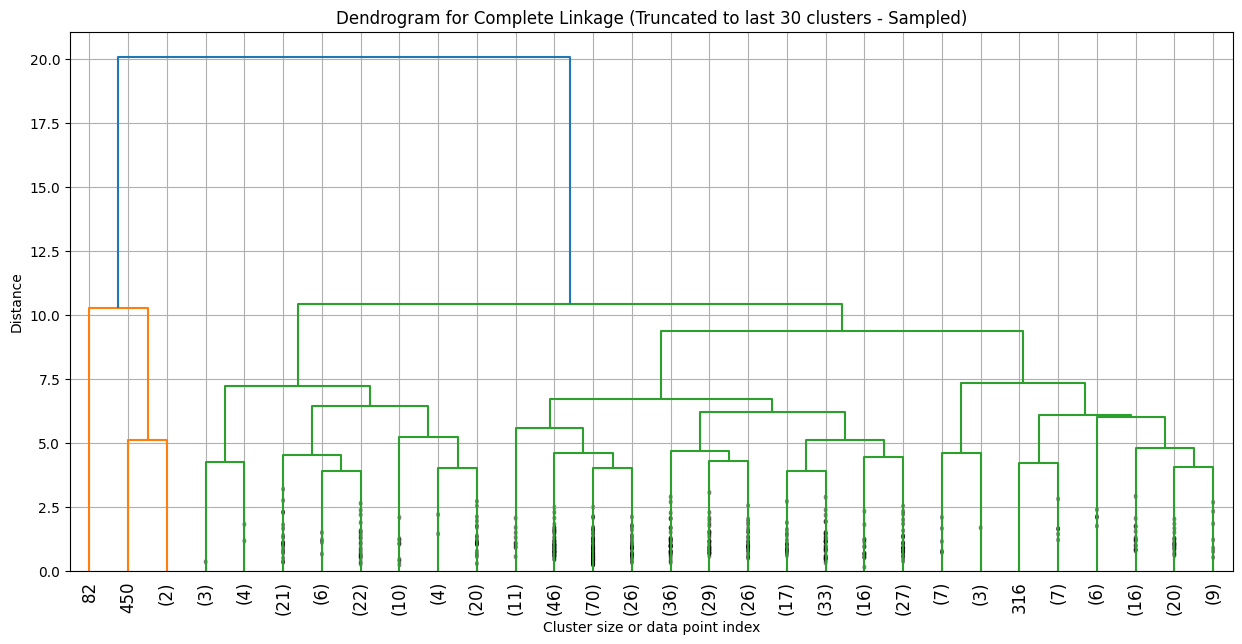


Generating dendrogram for 'average' linkage method (sample size: 500)...


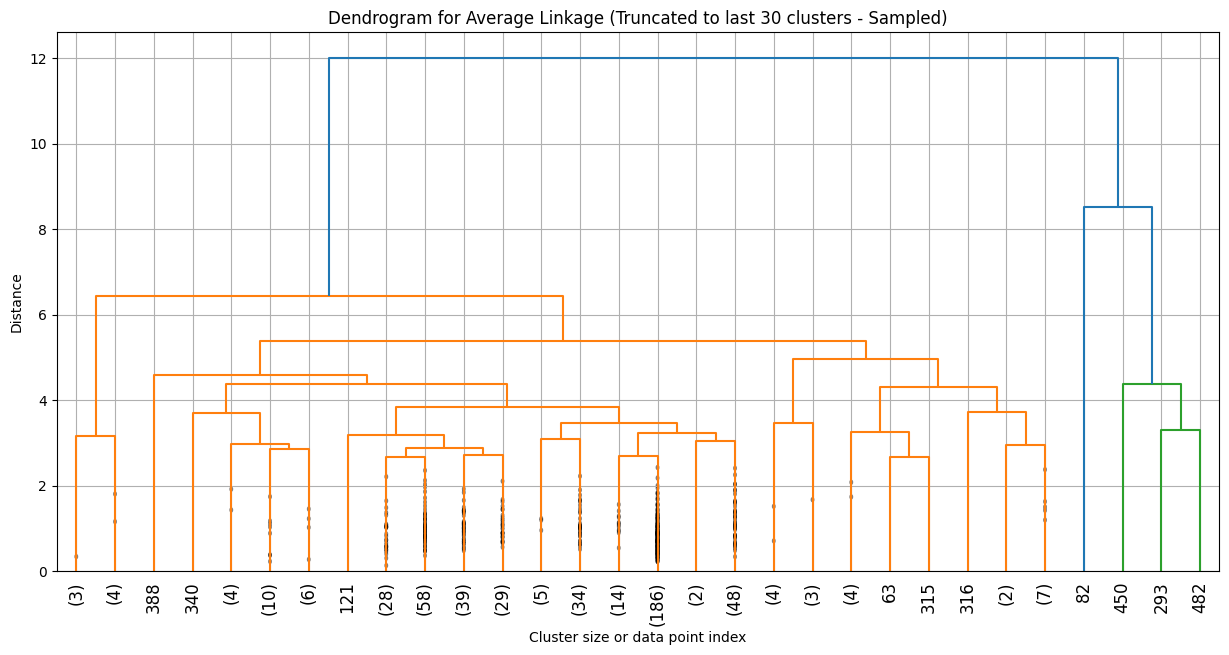


Generating dendrogram for 'ward' linkage method (sample size: 500)...


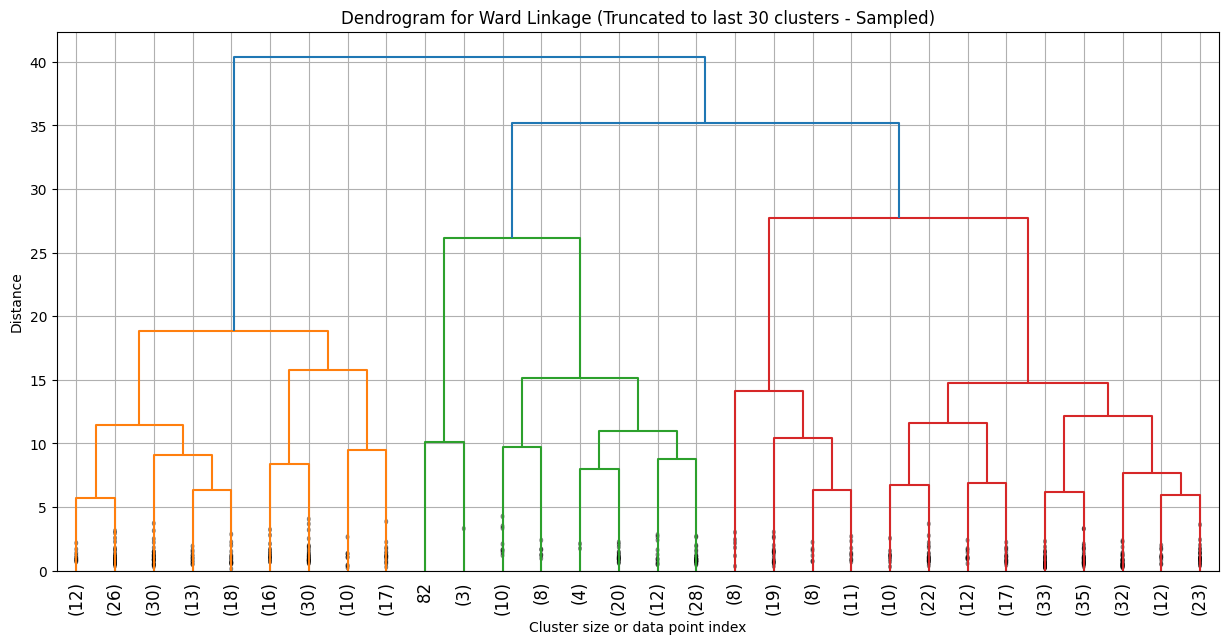

In [19]:
import sys
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Increase the recursion limit for dendrogram plotting
sys.setrecursionlimit(10000) # Increased to handle potentially deeper trees

# Define a list of linkage methods to test
linkage_methods = ['single', 'complete', 'average', 'ward']

# Take a random sample of the scaled DataFrame to avoid RecursionError for large datasets
# Adjust sample size as needed; 500 is a good starting point for visualization
sample_size = 500
df_scaled_sample = df_scaled.sample(n=sample_size, random_state=42)

# Iterate through each linkage method
for method in linkage_methods:
    print(f"\nGenerating dendrogram for '{method}' linkage method (sample size: {sample_size})...")
    # Compute the linkage matrix for the sampled data
    linkage_matrix_sample = linkage(df_scaled_sample, method=method)

    # Create a new figure for the dendrogram
    plt.figure(figsize=(15, 7))

    # Plot the dendrogram, truncating it to avoid RecursionError for large datasets
    dendrogram(
        linkage_matrix_sample,
        truncate_mode='lastp',
        p=30,  # Display only the last 30 merged clusters of the sample
        show_leaf_counts=True,
        leaf_rotation=90.,
        leaf_font_size=12.,
        show_contracted=True
    )

    # Set title and labels
    plt.title(f'Dendrogram for {method.capitalize()} Linkage (Truncated to last 30 clusters - Sampled)')
    plt.xlabel('Cluster size or data point index')
    plt.ylabel('Distance')
    plt.grid(True)
    plt.show()
